# Compare Results

Nguyễn Ngọc Hoàng Nam - B23DCCN585 | Assignment 04

**Bản mở rộng:** notebook này giữ nhóm 18 lượt seed 42 để giải thích thuật toán. Notebook **06** tổng hợp đầy đủ 54 lượt nhiều seed và 18 ablation; notebook **07** thực thi ví dụ số học dùng trong báo cáo 78 trang.

In [1]:
from pathlib import Path
import os, sys, json, subprocess
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Hãy mở notebook từ thư mục repository.'
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
from src.data import DATASETS, load_data, data_root
print('Python:', sys.version.split()[0])
print('Dữ liệu:', data_root())

Python: 3.10.20
Dữ liệu: E:\PTHTTM\ASG_04_data


## 1. Đối chiếu đầu ra thực tế

Đọc logits và nhãn đã lưu, tính lại metric, kiểm tra confusion matrix và epoch được chọn. Không huấn luyện hoặc chọn lại mô hình bằng test trong bước này.

In [2]:
from src.analyze import analyze
summary=analyze()
display(summary[['dataset','backend','variant','accuracy','macro_f1','top5_accuracy','test_loss','best_epoch','parameter_count','train_seconds']])

 dataset    backend  variant  accuracy  macro_f1  best_epoch
   mnist      numpy baseline    0.9869  0.986795           5
   mnist      numpy improved    0.9892  0.989140           5
   mnist    pytorch baseline    0.9863  0.986174           5
   mnist    pytorch improved    0.9903  0.990208           5
   mnist tensorflow baseline    0.9868  0.986695           5
   mnist tensorflow improved    0.9875  0.987486           4
 cifar10      numpy baseline    0.6315  0.628553          10
 cifar10      numpy improved    0.6643  0.663441           9
 cifar10    pytorch baseline    0.6303  0.626638          10
 cifar10    pytorch improved    0.6526  0.653112           9
 cifar10 tensorflow baseline    0.6301  0.626440          10
 cifar10 tensorflow improved    0.6602  0.658797           8
cifar100      numpy baseline    0.2823  0.273536          12
cifar100      numpy improved    0.3242  0.316807          12
cifar100    pytorch baseline    0.2884  0.277303          12
cifar100    pytorch impr

,dataset,backend,variant,accuracy,macro_f1,top5_accuracy,test_loss,best_epoch,parameter_count,train_seconds
0,mnist,numpy,baseline,0.9869,0.986795,0.9998,0.040283,5,52138,163.398558
1,mnist,numpy,improved,0.9892,0.989140,0.9999,0.031554,5,54666,754.722241
2,mnist,pytorch,baseline,0.9863,0.986174,0.9997,0.040365,5,52138,15.879581
3,mnist,pytorch,improved,0.9903,0.990208,0.9999,0.030867,5,54666,43.840935
4,mnist,tensorflow,baseline,0.9868,0.986695,0.9997,0.040432,5,52138,16.845447
5,mnist,tensorflow,improved,0.9875,0.987486,1.0000,0.037104,4,54666,22.118631
6,cifar10,numpy,baseline,0.6315,0.628553,0.9630,1.060018,10,67642,631.913585
7,cifar10,numpy,improved,0.6643,0.663441,0.9683,0.965280,9,70170,1680.222891
8,cifar10,pytorch,baseline,0.6303,0.626638,0.9624,1.061751,10,67642,45.123732
9,cifar10,pytorch,improved,0.6526,0.653112,0.9670,0.999070,9,70170,94.290242


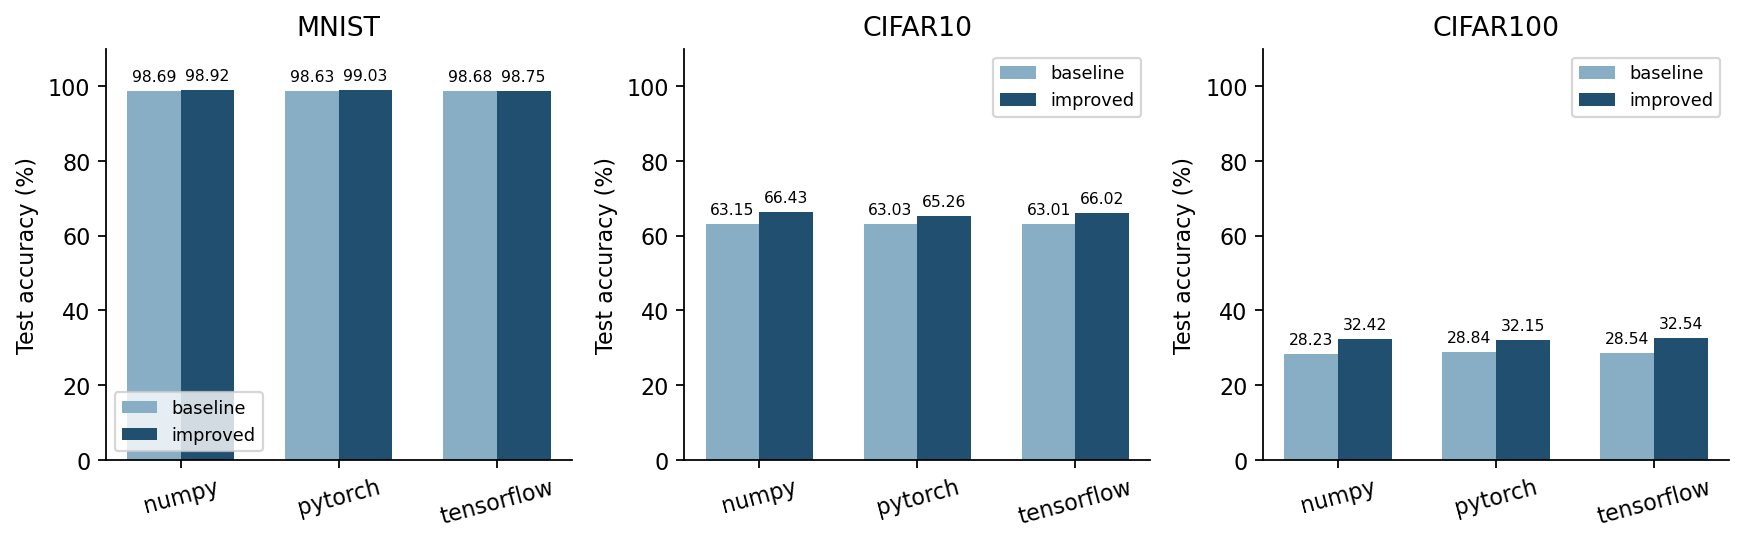

In [3]:
display(Image(filename=str(ROOT/'figures/accuracy_comparison.png')))

## 2. Mức thay đổi khi cải tiến

Độ chênh dưới đây tính theo **điểm phần trăm**: accuracy improved trừ accuracy baseline. Không gọi chênh lệch này là phần trăm tăng tương đối.

In [4]:
delta=summary.pivot(index=['dataset','backend'],columns='variant',values='accuracy')
delta['delta_percentage_points']=100*(delta.improved-delta.baseline)
display(delta)

variant              baseline  improved  delta_percentage_points
dataset  backend                                                
cifar10  numpy         0.6315    0.6643                     3.28
         pytorch       0.6303    0.6526                     2.23
         tensorflow    0.6301    0.6602                     3.01
cifar100 numpy         0.2823    0.3242                     4.19
         pytorch       0.2884    0.3215                     3.31
         tensorflow    0.2854    0.3254                     4.00
mnist    numpy         0.9869    0.9892                     0.23
         pytorch       0.9863    0.9903                     0.40
         tensorflow    0.9868    0.9875                     0.07

## 3. Learning curves và lỗi dự đoán

Mô hình minh họa mỗi dataset được chọn theo validation loss thấp nhất trong sáu lượt. Các ảnh lỗi là 10 dự đoán sai có confidence cao nhất; đây là tập lỗi có chủ đích để khảo sát, không đại diện cho tỷ lệ lỗi toàn test.

### MNIST

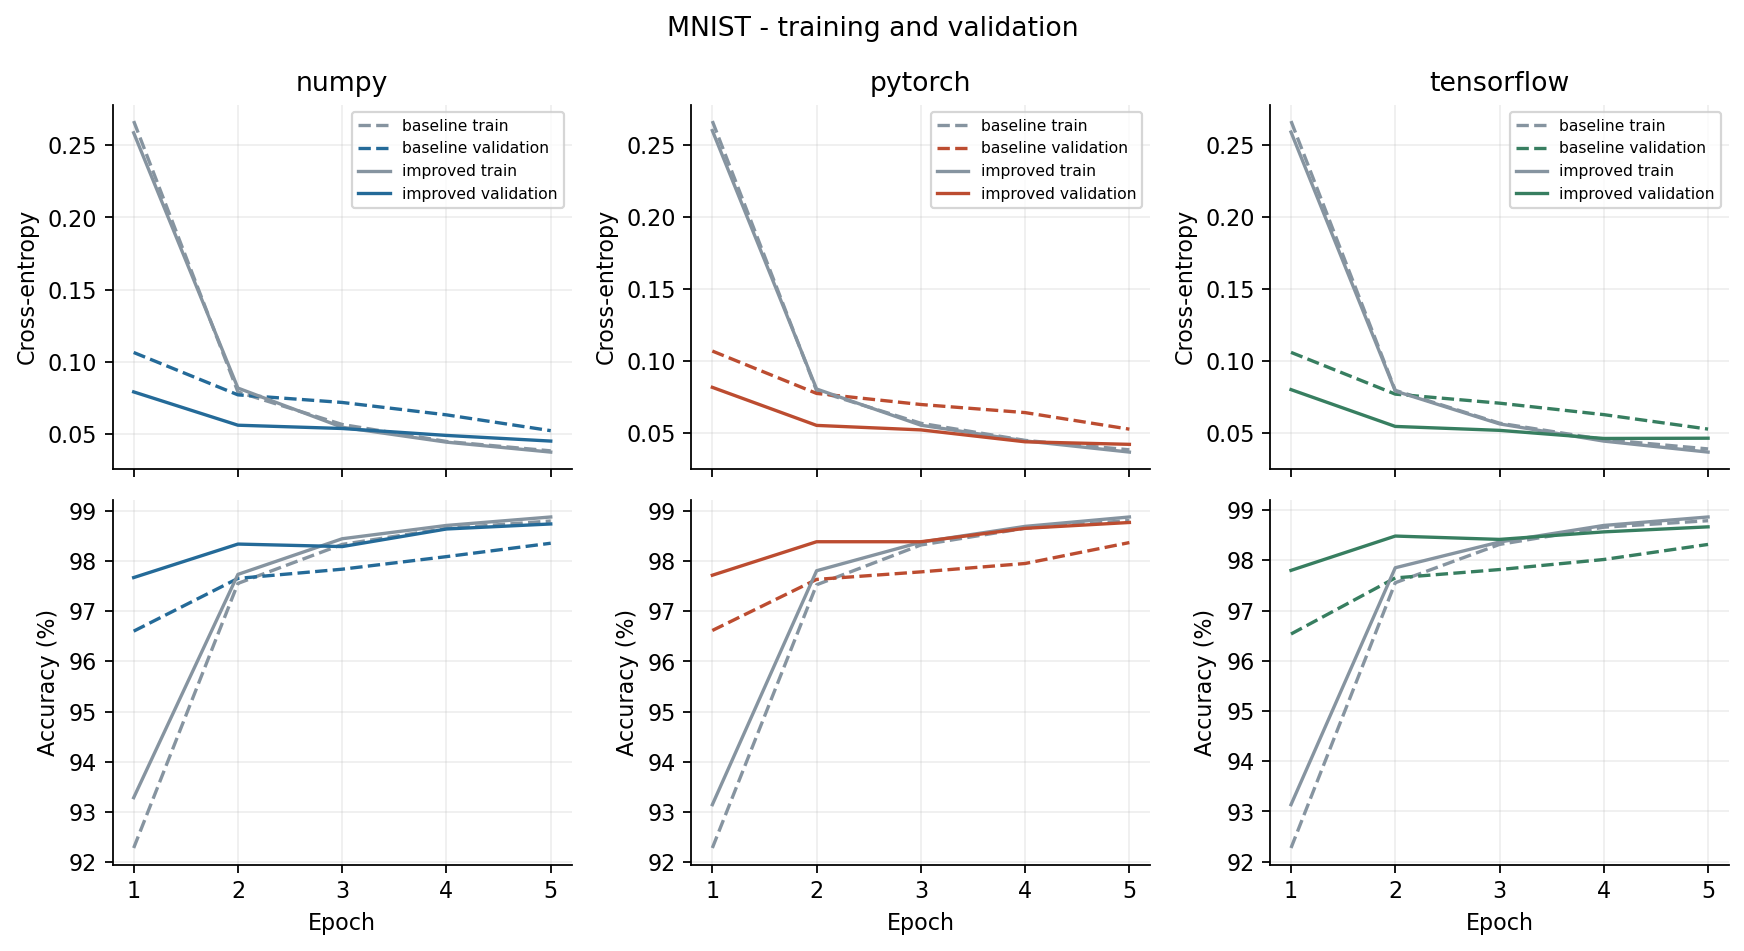

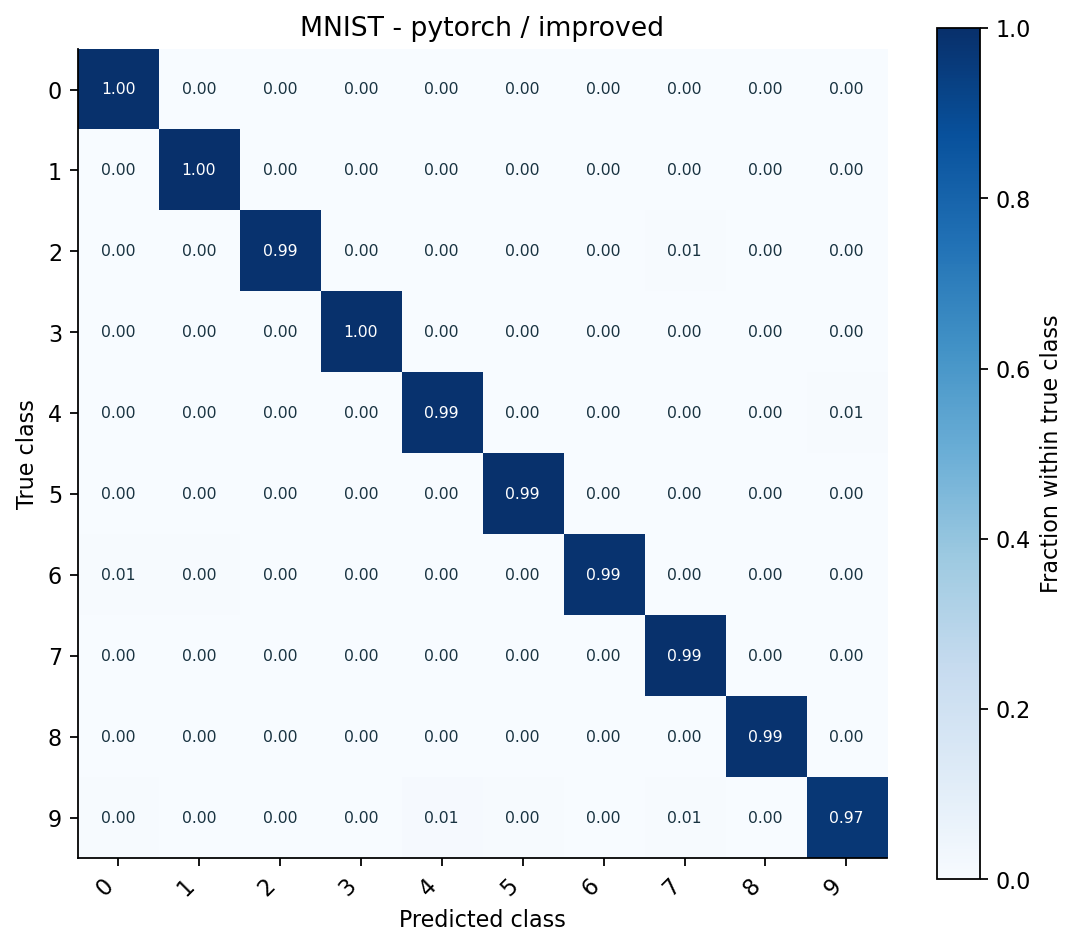

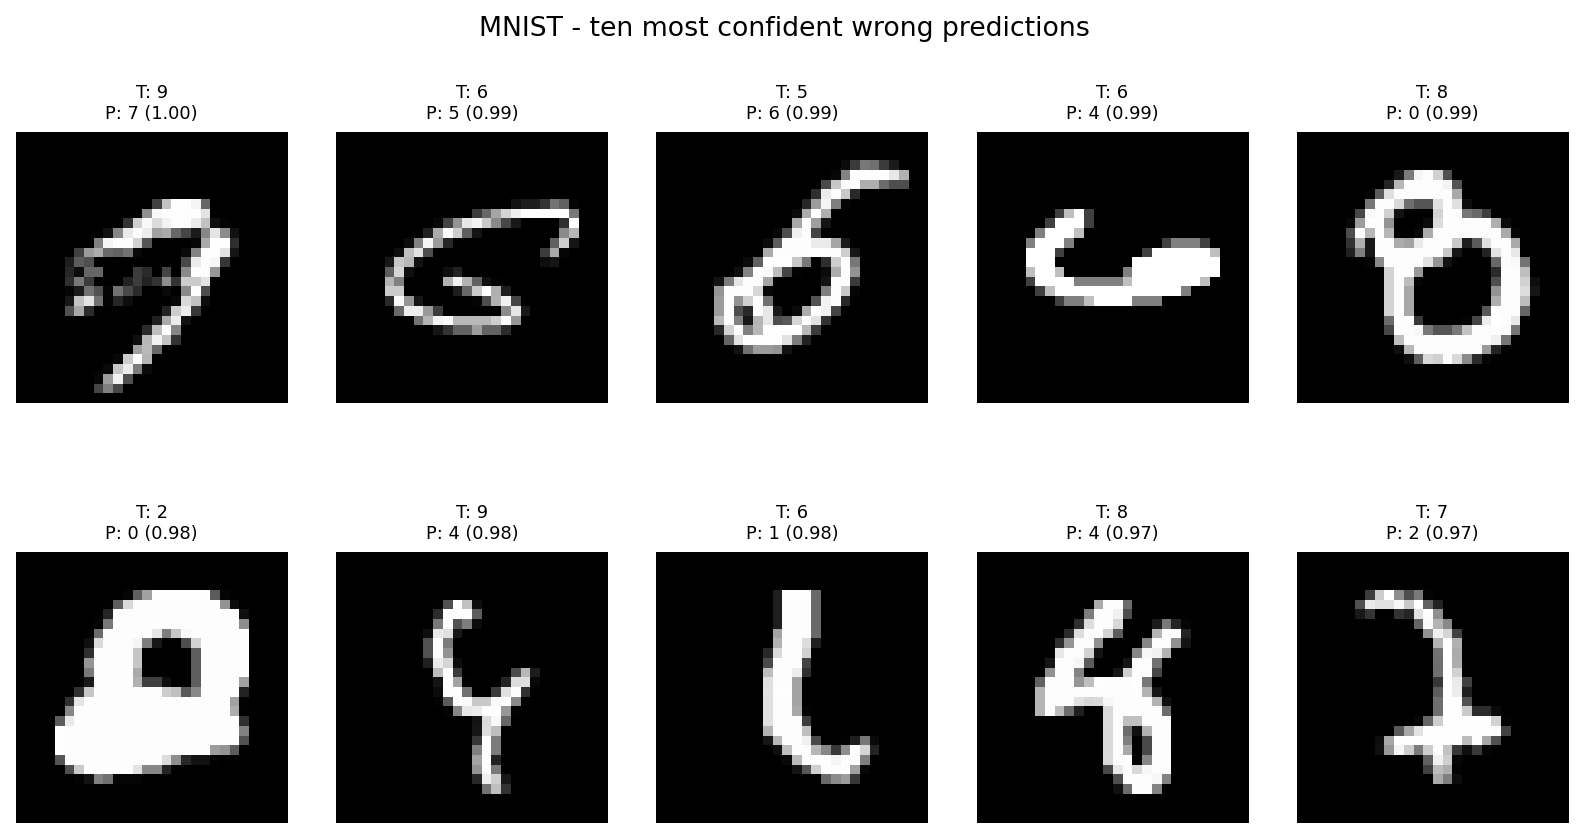

,true,predicted,count
0,9,4,8
1,4,9,7
2,9,7,6
3,2,7,6
4,9,0,5
5,9,5,5
6,6,0,5
7,6,1,4
8,7,2,4
9,8,5,3


### CIFAR10

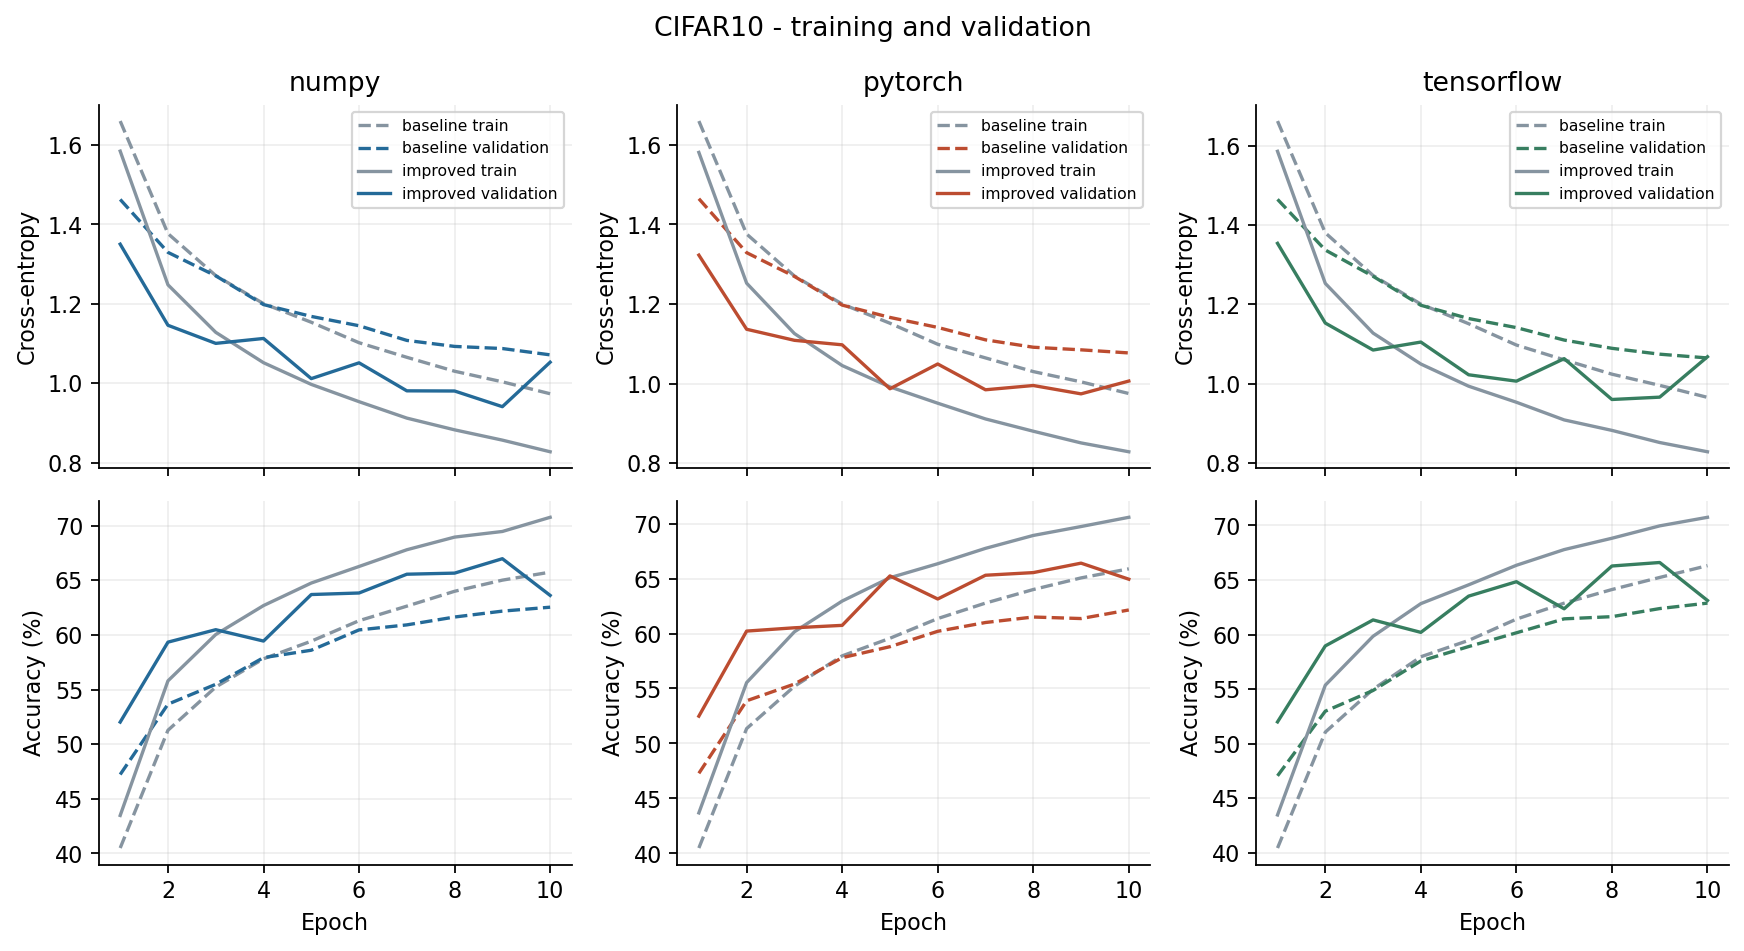

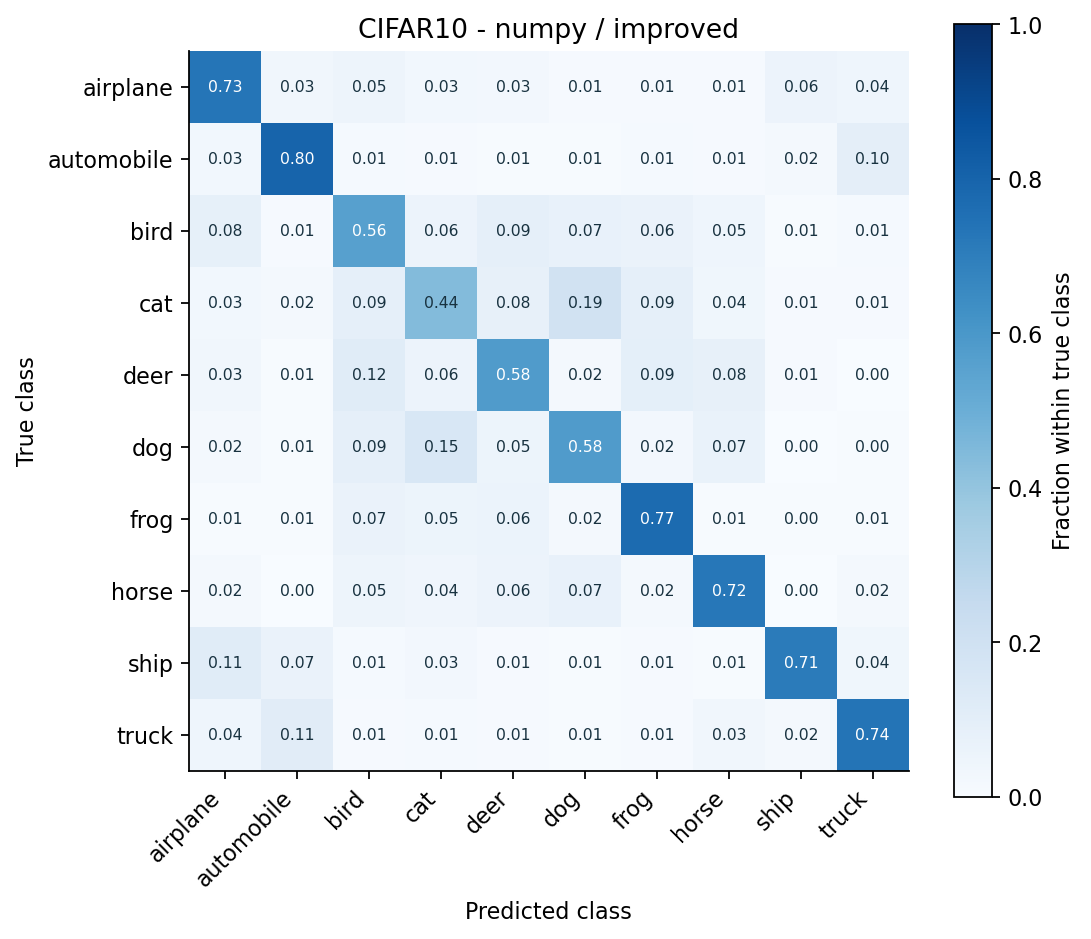

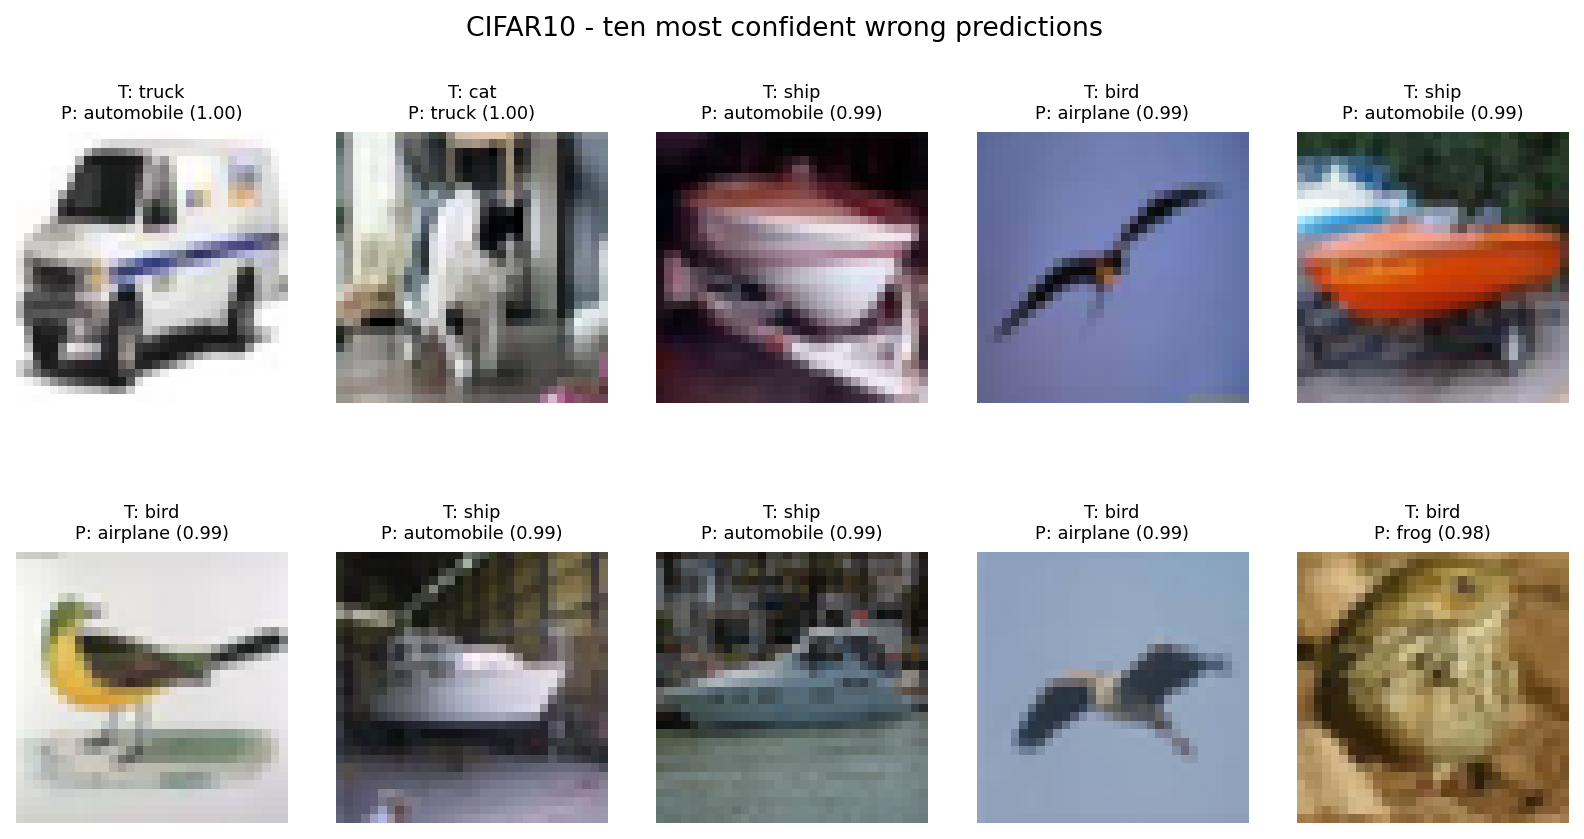

,true,predicted,count
0,cat,dog,193
1,dog,cat,154
2,deer,bird,117
3,ship,airplane,114
4,truck,automobile,113
5,automobile,truck,95
6,deer,frog,92
7,cat,bird,89
8,cat,frog,89
9,bird,deer,88


### CIFAR100

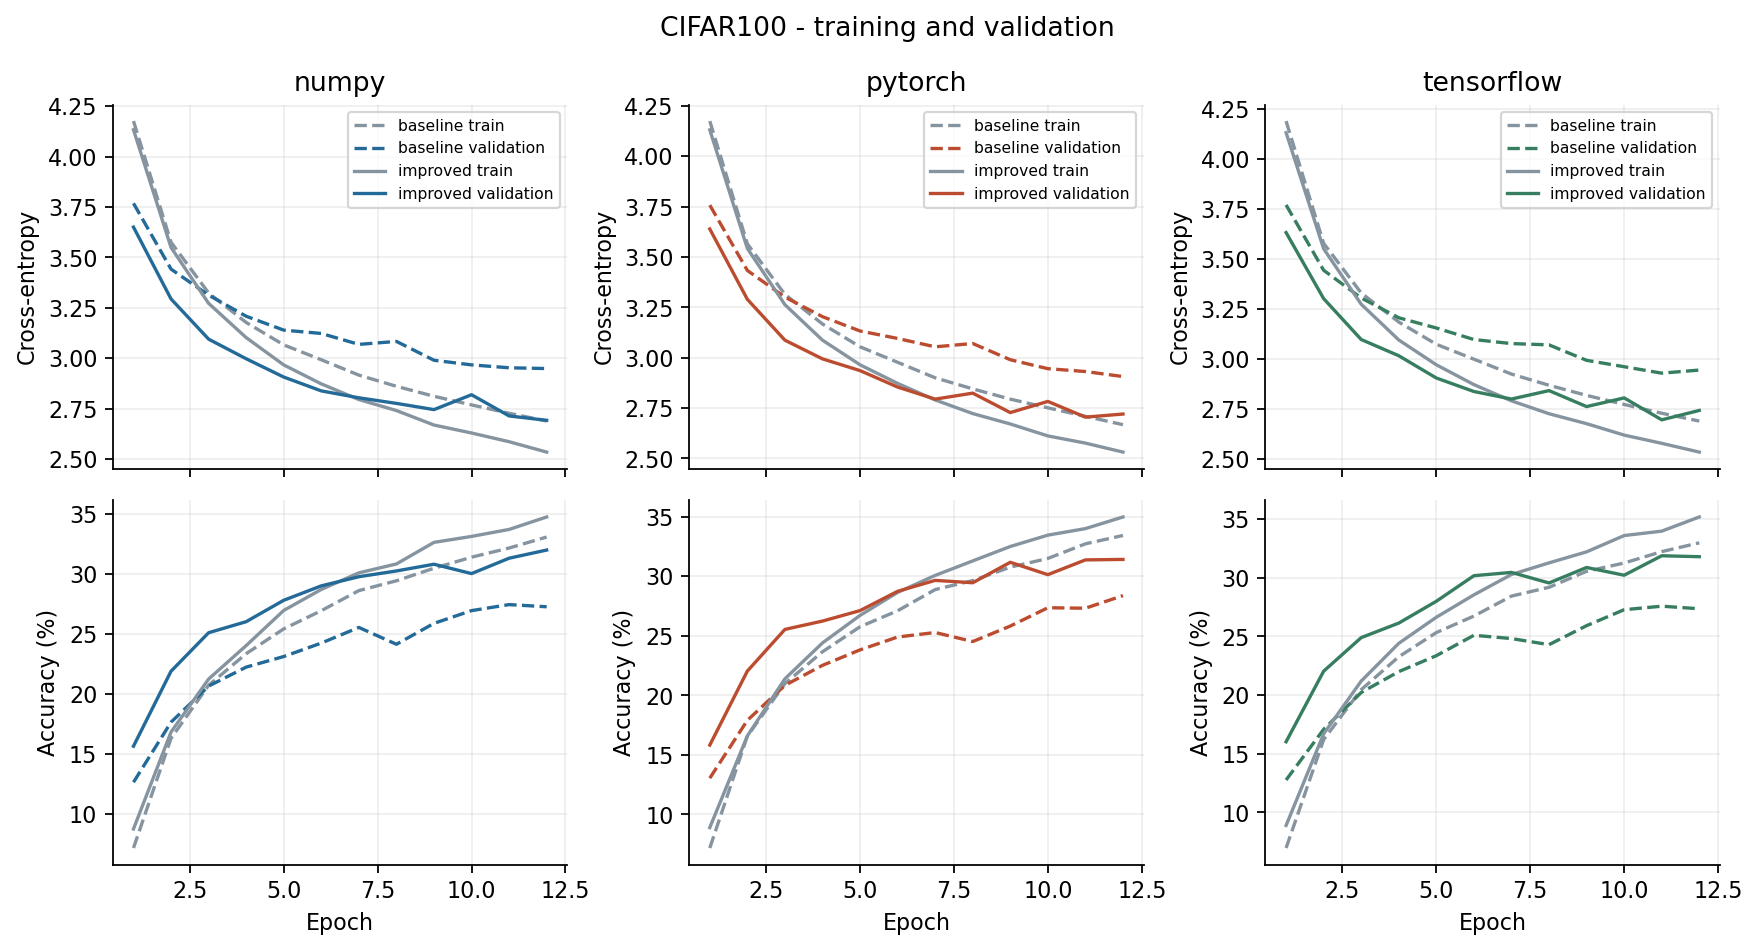

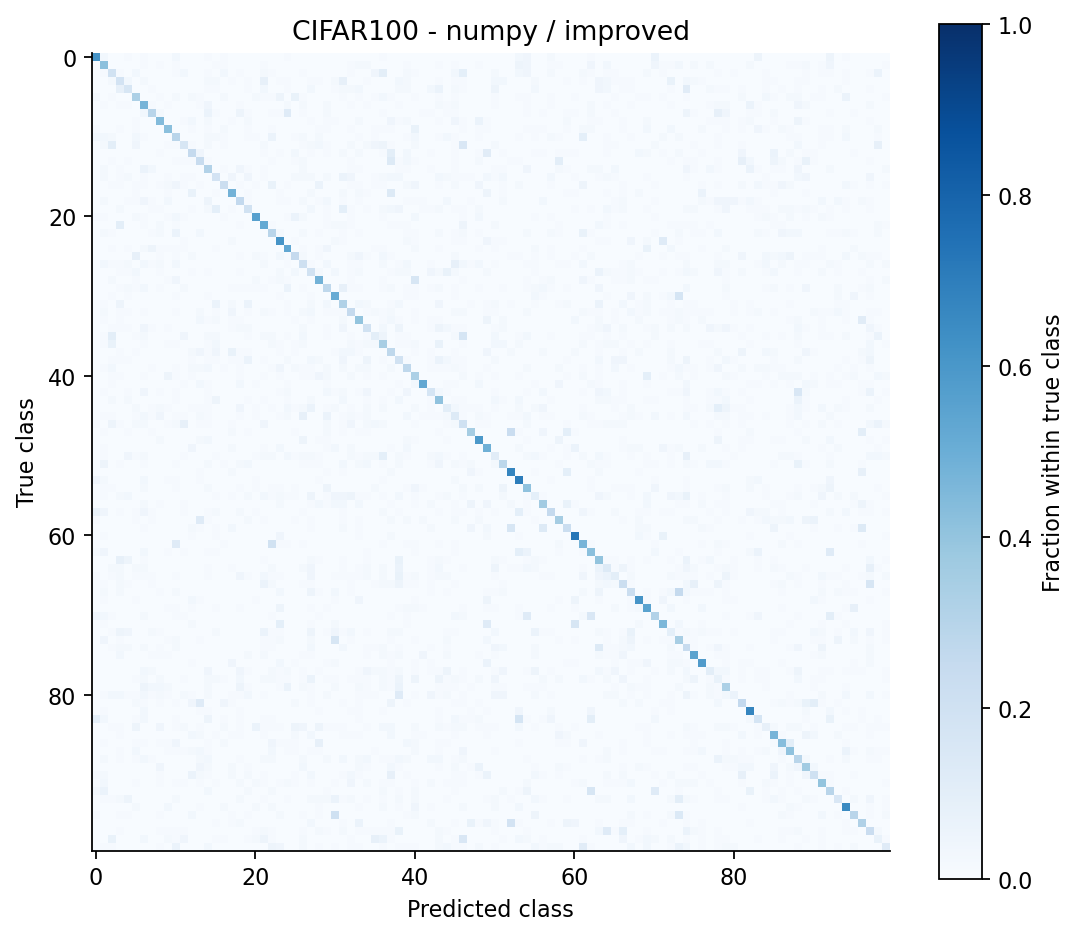

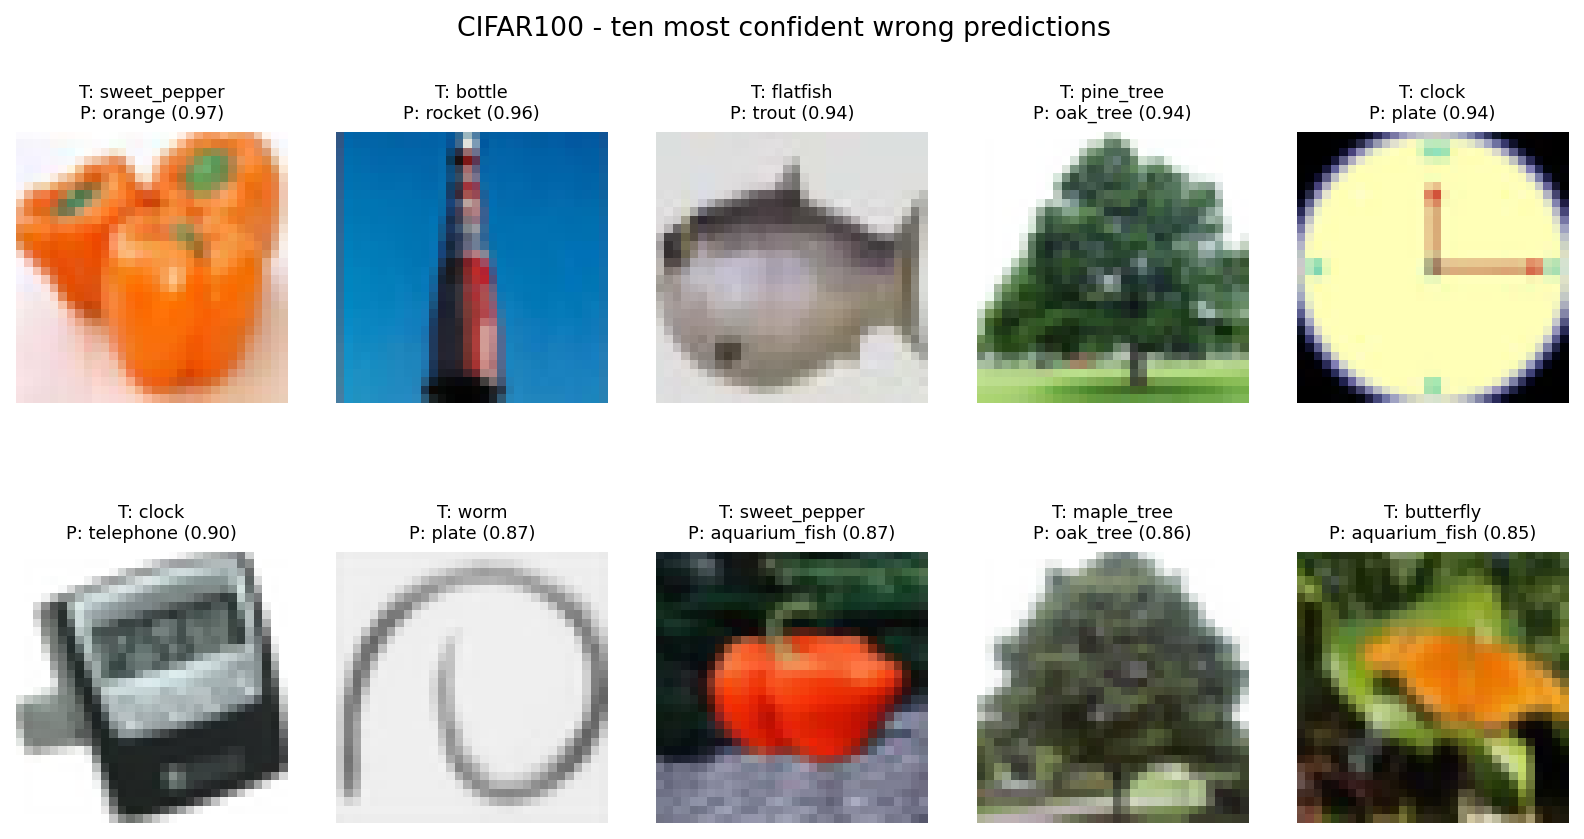

,true,predicted,count
0,ray,shark,25
1,maple_tree,oak_tree,23
2,whale,dolphin,20
3,plate,clock,19
4,willow_tree,oak_tree,18
5,sweet_pepper,orange,17
6,girl,man,17
7,dolphin,shark,17
8,shark,dolphin,16
9,sea,plain,16


In [5]:
for name in DATASETS:
    display(Markdown('### '+name.upper()))
    display(Image(filename=str(ROOT/'figures'/f'{name}_curves.png')))
    display(Image(filename=str(ROOT/'figures'/f'{name}_confusion.png')))
    display(Image(filename=str(ROOT/'figures'/f'{name}_errors.png')))
    display(pd.DataFrame(json.loads((ROOT/'results'/f'{name}_error_analysis.json').read_text())['worst_pairs']))

## 4. Độ nhạy với trùng ảnh CIFAR-100

In [6]:
sensitivity=ROOT/'results/cifar100_duplicate_sensitivity.json'
if sensitivity.exists():display(pd.DataFrame(json.loads(sensitivity.read_text())))

,backend,variant,official_accuracy,unseen_pixel_accuracy,retained_test_images,excluded_test_images
0,numpy,baseline,0.2823,0.282282,9990,10
1,numpy,improved,0.3242,0.324024,9990,10
2,pytorch,baseline,0.2884,0.288288,9990,10
3,pytorch,improved,0.3215,0.321421,9990,10
4,tensorflow,baseline,0.2854,0.285485,9990,10
5,tensorflow,improved,0.3254,0.325425,9990,10


## 5. Kết luận có thể rút ra

Mạng nhỏ đủ giải MNIST khá tốt nhưng ảnh tự nhiên, đặc biệt CIFAR-100, vẫn khó. Kết quả cải tiến cần đối chiếu với số tham số, số epoch và validation. So sánh một seed không đủ để khẳng định ưu thế có ý nghĩa thống kê giữa các framework.

Phiên bản improved thay nhiều thành phần cùng lúc, vì vậy thí nghiệm chính không tách được đóng góp riêng của BN, residual và dropout. Pilot chỉ khảo sát việc thêm BN ở phần dense; không thay thế ablation đầy đủ. Bản mở rộng đã bổ sung nhiều seed và ablation từng thành phần trong notebook 06. Augmentation và lịch learning rate vẫn là hướng chưa thực nghiệm. Nhận xét một seed ở đây chỉ mô tả nhóm cũ; kết luận tổng hợp cần đọc cùng notebook 06.

Xem báo cáo PDF trong `report/` để đọc phân tích số liệu và giới hạn đầy đủ.